# Day 10: Mall Customer EDA Notebook (Visualizations - Pure Matplotlib)
Focusing on univariate and bivariate visualizations of the Mall Customers dataset using pure Matplotlib.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set visual style
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12


### Step 1: Load Dataset


In [2]:
df = pd.read_csv('Mall_Customers.csv')
print("Data loaded successfully!")


Data loaded successfully!


### Step 2: Check Shape & Columns


In [3]:
print("Columns:", list(df.columns))
print("Shape:", df.shape)


Columns: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Shape: (200, 5)


### Step 3: View Dataset Information


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


### Step 4: Check Data Types


In [5]:
df.dtypes


CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

### Step 5 & 6: Missing Values Analysis


In [6]:
print("Missing values per column:")
df.isnull().sum()


Missing values per column:


CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### Step 7 & 8: Duplicate Records Analysis


In [7]:
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


### Step 9: Generate Statistical Summary


In [8]:
print("Median Annual Income:", df["Annual Income (k$)"].median())
print("Mean Annual Income:", df["Annual Income (k$)"].mean())
print("Min Annual Income:", df["Annual Income (k$)"].min())
print("Max Annual Income:", df["Annual Income (k$)"].max())
display(df.describe())


Median Annual Income: 61.5
Mean Annual Income: 60.56
Min Annual Income: 15
Max Annual Income: 137


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### Step 10: Outlier Detection


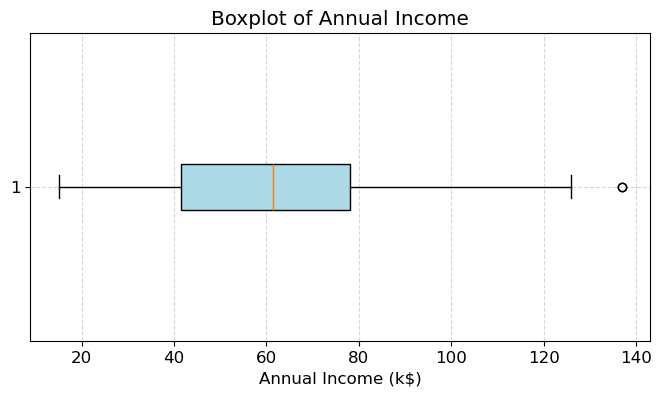

In [9]:
plt.figure(figsize=(8, 4))
plt.boxplot(df["Annual Income (k$)"], vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.title("Boxplot of Annual Income")
plt.xlabel("Annual Income (k$)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


### Step 11: Perform Univariate Analysis (Gender & Age Distributions)


Gender Counts:
Genre
Female    112
Male       88
Name: count, dtype: int64


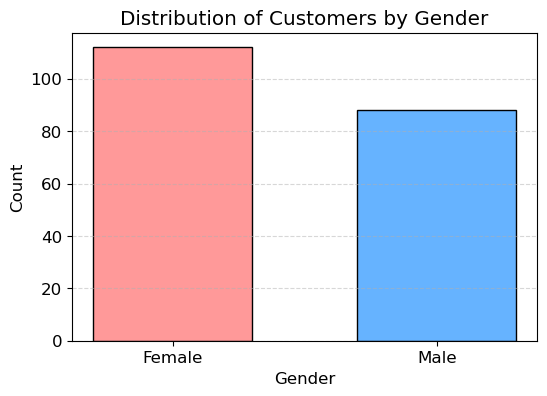

In [10]:
# Check customer counts by gender
gender_counts = df['Genre'].value_counts()
print("Gender Counts:")
print(gender_counts)

# 1. Bar Plot of Gender Distribution (Matplotlib)
plt.figure(figsize=(6, 4))
plt.bar(gender_counts.index, gender_counts.values, color=["#ff9999", "#66b3ff"], edgecolor="black", width=0.6)
plt.title('Distribution of Customers by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.show()


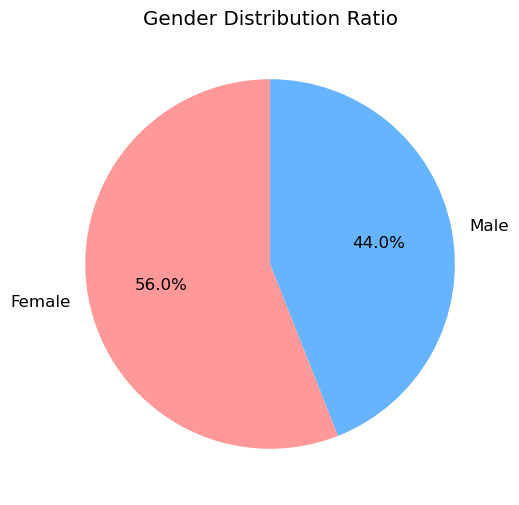

In [11]:
# 2. Pie Chart of Gender Distribution (Matplotlib)
plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=["Female", "Male"], autopct="%1.1f%%", startangle=90, colors=["#ff9999", "#66b3ff"])
plt.title("Gender Distribution Ratio")
plt.show()


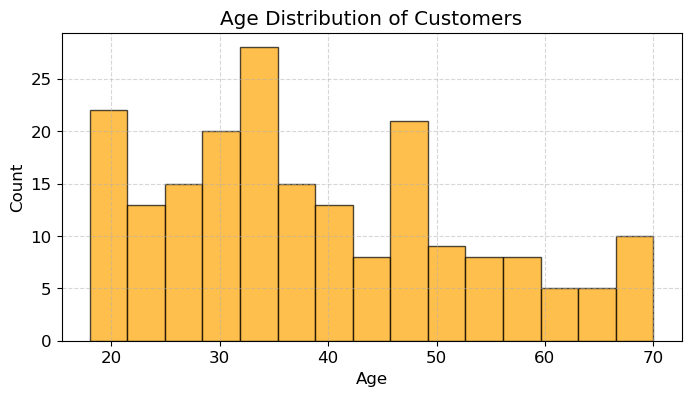

In [12]:
# 3. Age distribution
plt.figure(figsize=(8, 4))
plt.hist(df["Age"], bins=15, color="orange", edgecolor="black", alpha=0.7)
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


### Step 12: Perform Bivariate Analysis (Scatter Plots)


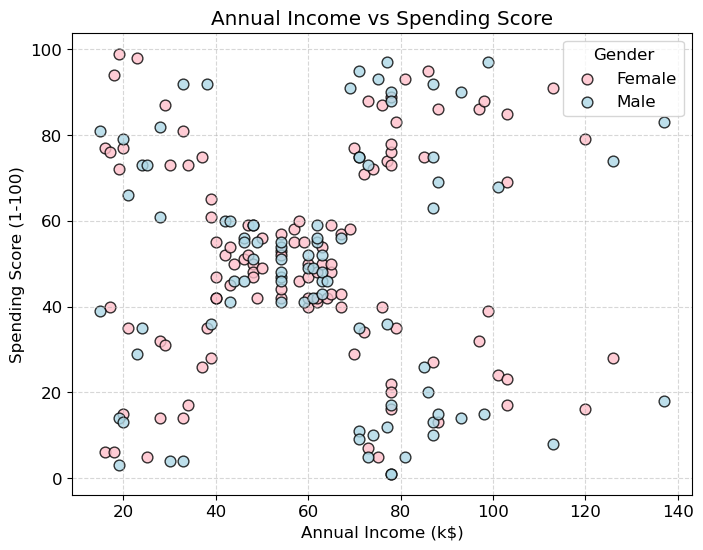

In [13]:
# 1. Annual Income vs Spending Score Scatter Plot (colored by gender manually)
plt.figure(figsize=(8, 6))
females = df[df["Genre"] == "Female"]
males = df[df["Genre"] == "Male"]

plt.scatter(females['Annual Income (k$)'], females['Spending Score (1-100)'], color="pink", label="Female", alpha=0.8, s=60, edgecolor="black")
plt.scatter(males['Annual Income (k$)'], males['Spending Score (1-100)'], color="lightblue", label="Male", alpha=0.8, s=60, edgecolor="black")

plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Gender')
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


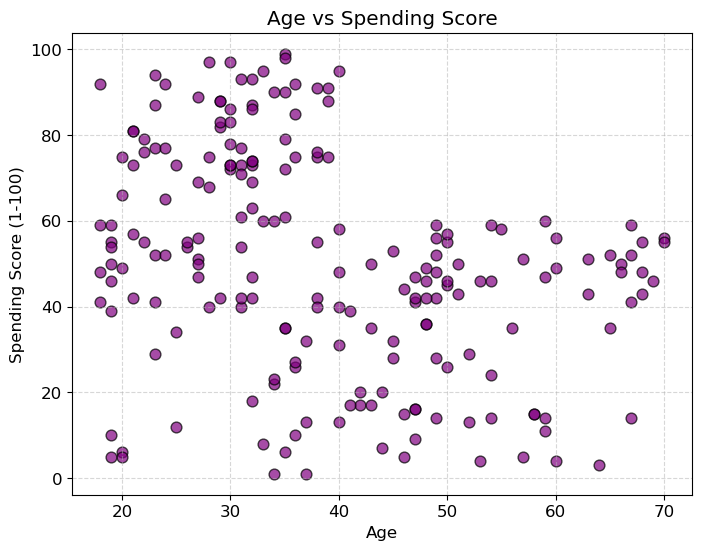

In [14]:
# 2. Age vs Spending Score Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(df['Age'], df['Spending Score (1-100)'], color="purple", alpha=0.7, s=60, edgecolor="black")
plt.title('Age vs Spending Score')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


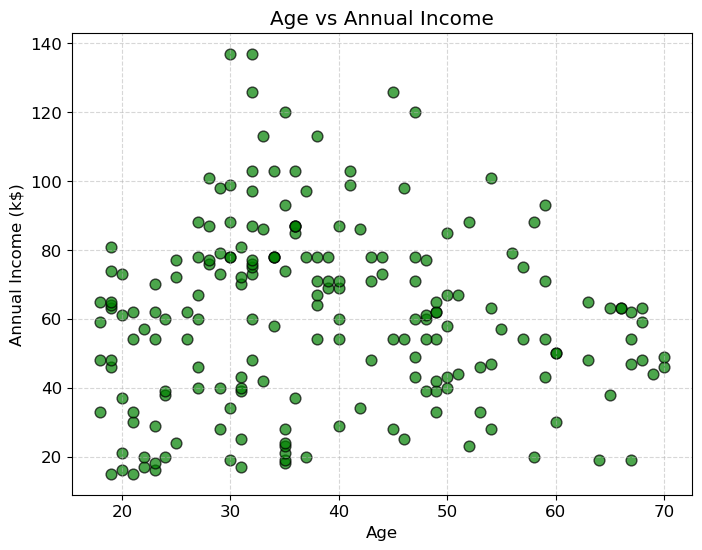

In [15]:
# 3. Age vs Annual Income Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(df['Age'], df['Annual Income (k$)'], color="green", alpha=0.7, s=60, edgecolor="black")
plt.title('Age vs Annual Income')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


### Step 13: Correlation Analysis


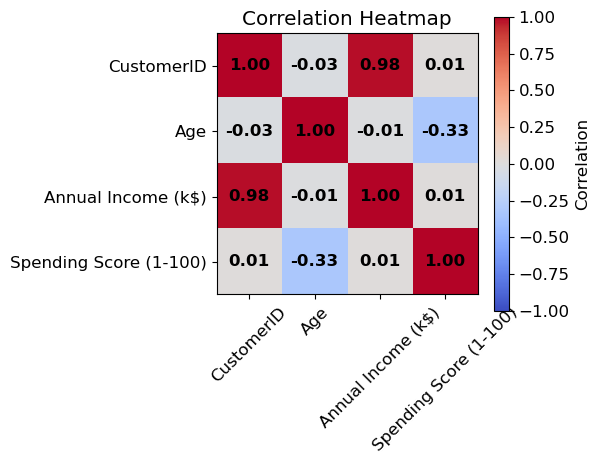

In [16]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(6, 5))
plt.imshow(corr, cmap="coolwarm", interpolation="none", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontweight="bold")

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


### Step 14: Feature Engineering


   Age  AgeCategory
0   19        Youth
1   21        Youth
2   20        Youth
3   23        Youth
4   31  Middle-Aged


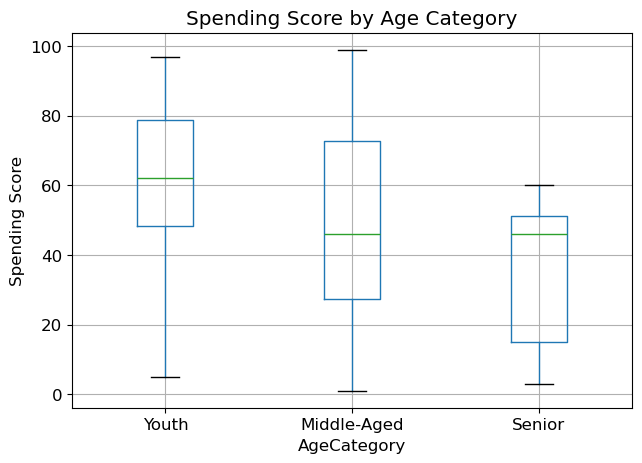

In [17]:
# Segment Customers into age categories
df["AgeCategory"] = pd.cut(df["Age"], bins=[0, 30, 50, 100], labels=["Youth", "Middle-Aged", "Senior"])
print(df[["Age", "AgeCategory"]].head())

# Visualize Spending Score by Age Category using Pandas Boxplot
df.boxplot(column="Spending Score (1-100)", by="AgeCategory", grid=True, figsize=(7, 5))
plt.title("Spending Score by Age Category")
plt.suptitle("")
plt.ylabel("Spending Score")
plt.show()


### Step 15: Draw Conclusions and Insights
1. **Gender Ratio**: Females represent a larger share of the customers (56%) compared to males (44%).
2. **Spending Habits by Age**: Younger customers (under 30 and middle-aged) tend to have higher spending scores compared to older individuals, as highlighted by the Age Category boxplot.
3. **Cluster Pattern**: The Annual Income vs Spending Score shows distinct grouping shapes, which are useful for customer segmentation algorithms like K-Means Clustering.


# --- Machine Learning: K-Means Clustering & Gender Classification ---
In this section, we train a K-Means Clustering model to segment customers into distinct behavioral groups, and then train classification models to predict a customer's gender based on their age, annual income, and spending score.

### Part 1: Unsupervised Learning - K-Means Clustering

C:\Users\Aditya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Aditya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Aditya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Aditya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

C:\Users\Aditya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


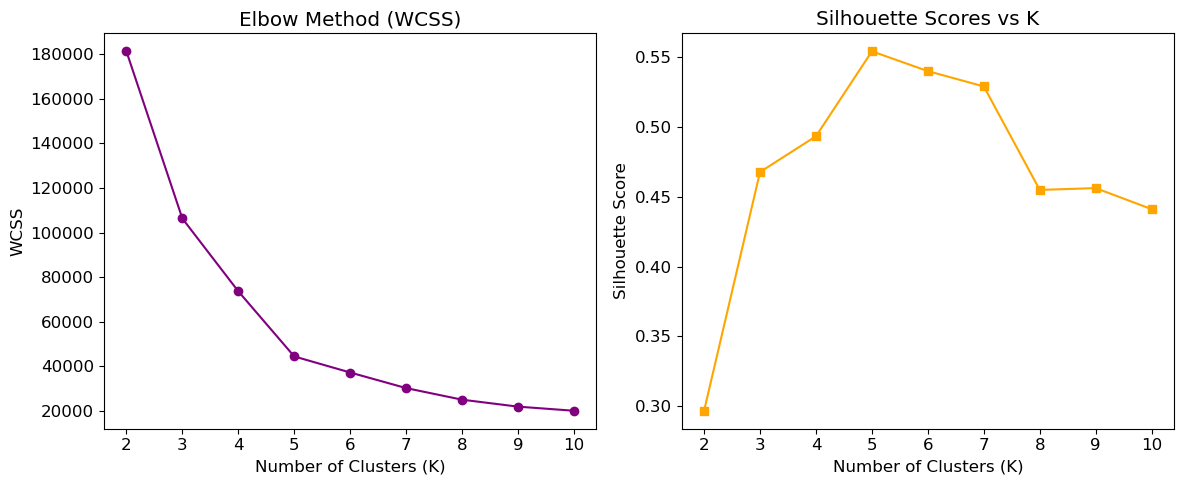

In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Prepare clustering features: Annual Income and Spending Score
X_clust = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Determine optimal number of clusters using Elbow Method
wcss = []
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clust)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_clust, kmeans.labels_))

# Plot WCSS (Elbow Method)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(2, 11), wcss, marker='o', color='purple')
plt.title('Elbow Method (WCSS)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, marker='s', color='orange')
plt.title('Silhouette Scores vs K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()


C:\Users\Aditya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Silhouette Score for K=5: 0.5539


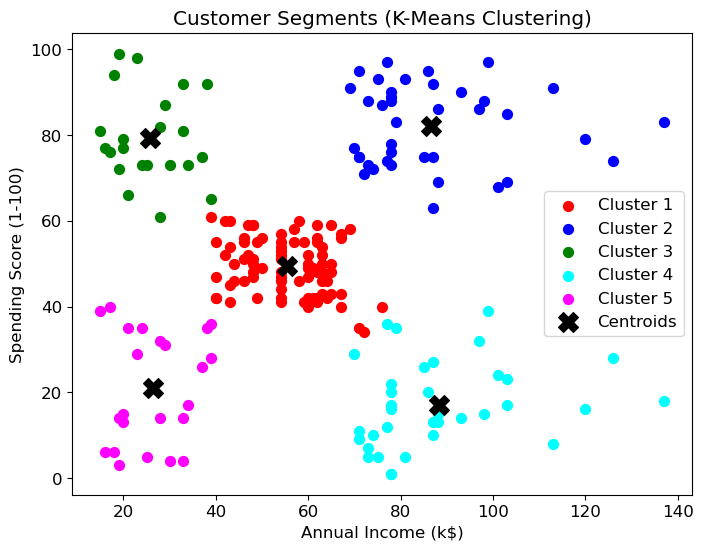

In [19]:
# Train K-Means with optimal K=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_transform(X_clust).argmin(axis=1) # fit labels
labels = kmeans.labels_

print(f"Silhouette Score for K=5: {silhouette_score(X_clust, labels):.4f}")

# Plot Segmented Clusters
plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
for i in range(5):
    clust_data = df[df['Cluster'] == i]
    plt.scatter(clust_data['Annual Income (k$)'], clust_data['Spending Score (1-100)'], 
                color=colors[i], label=f'Cluster {i+1}', s=50)

# Plot cluster centers
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            color='black', marker='X', s=200, label='Centroids')
plt.title('Customer Segments (K-Means Clustering)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()


### Part 2: Supervised Learning - Gender Classification

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Prepare features and target
ml_df = df[['Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']].copy()
le = LabelEncoder()
ml_df['Genre'] = le.fit_transform(ml_df['Genre'])

X = ml_df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
y = ml_df['Genre']

# Split data 80-20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train models
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Predict
lr_preds = lr_model.predict(X_test)
dt_preds = dt_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_preds) * 100
dt_acc = accuracy_score(y_test, dt_preds) * 100

print(f"Logistic Regression Test Accuracy: {lr_acc:.2f}%")
print(f"Decision Tree Test Accuracy: {dt_acc:.2f}%")


Logistic Regression Test Accuracy: 50.00%
Decision Tree Test Accuracy: 57.50%


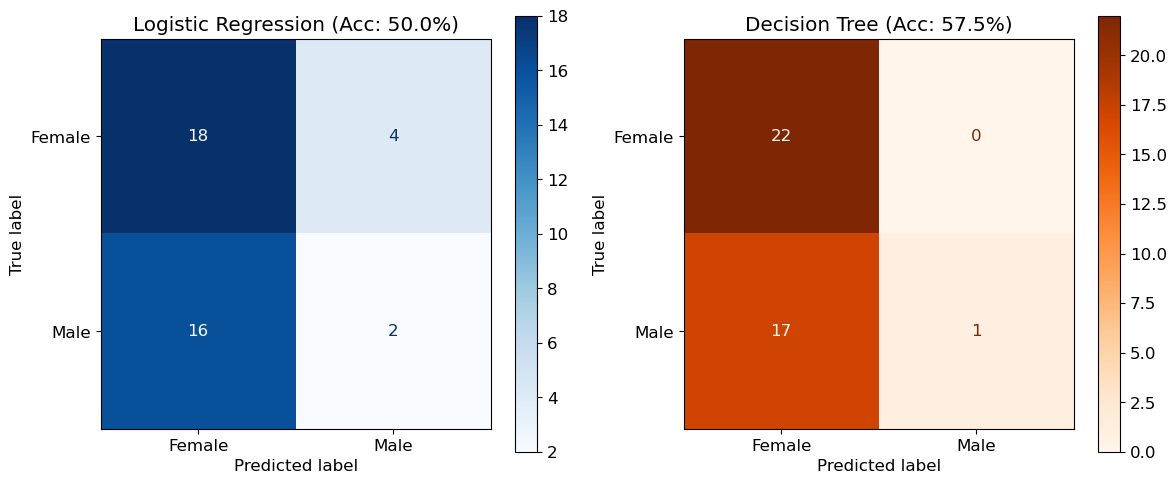


--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

      Female       0.56      1.00      0.72        22
        Male       1.00      0.06      0.11        18

    accuracy                           0.57        40
   macro avg       0.78      0.53      0.41        40
weighted avg       0.76      0.57      0.44        40



In [21]:
# Plot Confusion Matrix for Gender Classifier
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

lr_cm = confusion_matrix(y_test, lr_preds)
ConfusionMatrixDisplay(lr_cm, display_labels=le.classes_).plot(cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title(f'Logistic Regression (Acc: {lr_acc:.1f}%)')

dt_cm = confusion_matrix(y_test, dt_preds)
ConfusionMatrixDisplay(dt_cm, display_labels=le.classes_).plot(cmap='Oranges', ax=axes[1], values_format='d')
axes[1].set_title(f'Decision Tree (Acc: {dt_acc:.1f}%)')

plt.tight_layout()
plt.show()

print("\n--- Decision Tree Classification Report ---")
print(classification_report(y_test, dt_preds, target_names=le.classes_))
